In [65]:
# HW3: Classification on SPAMBASE

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

np.random.seed(4400)
RANDOM_STATE = 4400
TEST_SIZE = 0.25
THRESHOLDS_P1 = [0.25, 0.5, 0.75, 0.9]
ROC_THRESHOLDS = [i / 10 for i in range(11)]


In [66]:
# Section 1: Load SPAMBASE data from local spambase/ folder

import os

NAMES_PATH = "spambase/spambase.names"
DATA_PATH  = "spambase/spambase.data"

print("Current working directory:", os.getcwd())
print("Expecting files at:", NAMES_PATH, "and", DATA_PATH)

# Parse feature names from .names
with open(NAMES_PATH, "r") as f:
    names_text = f.readlines()

feature_names = []
for line in names_text:
    line = line.strip()
    if ": continuous" in line and "word_freq_" in line:
        feature_names.append(line.split(":")[0].strip())
    elif ": continuous" in line and "char_freq_" in line:
        feature_names.append(line.split(":")[0].strip())
    elif any(key in line for key in [
        "capital_run_length_average",
        "capital_run_length_longest",
        "capital_run_length_total",
    ]):
        name = line.split(":")[0].strip()
        if name not in feature_names:
            feature_names.append(name)

spam_df = pd.read_csv(DATA_PATH, header=None)

X = spam_df.iloc[:, :-1].values
y = spam_df.iloc[:, -1].values.astype(int)

if len(feature_names) != X.shape[1]:
    feature_names = [f"x{i}" for i in range(X.shape[1])]

print("Data shape:", X.shape)
print("Class counts:", {c: int((y == c).sum()) for c in np.unique(y)})
print("Number of feature names:", len(feature_names))

Current working directory: /Users/easonxie/Desktop/CS/DS4400/HW
Expecting files at: spambase/spambase.names and spambase/spambase.data
Data shape: (4601, 57)
Class counts: {np.int64(0): 2788, np.int64(1): 1813}
Number of feature names: 57


In [67]:
# Section 2: Train/test split + scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train shape:", X_train_sc.shape)
print("Test shape:", X_test_sc.shape)

Train shape: (3450, 57)
Test shape: (1151, 57)


In [68]:
# Section 3: Shared metric utilities

from typing import Tuple


def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[int, int, int, int]:
    """Return (tn, fp, fn, tp) for binary labels 0/1."""
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    return tn, fp, fn, tp


def metrics_from_counts(tn: int, fp: int, fn: int, tp: int) -> dict:
    total = tn + fp + fn + tp
    accuracy = (tp + tn) / total if total > 0 else 0.0
    error = 1.0 - accuracy
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "accuracy": accuracy,
        "error": error,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def print_metrics(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    m = metrics_from_counts(tn, fp, fn, tp)
    print(f"{name}:")
    print(f"  Confusion matrix (tn, fp, fn, tp): {tn}, {fp}, {fn}, {tp}")
    print(f"  Accuracy:  {m['accuracy']:.4f} | Error: {m['error']:.4f}")
    print(f"  Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | F1: {m['f1']:.4f}\n")


def predict_with_threshold(proba: np.ndarray, T: float) -> np.ndarray:
    """Convert predicted probabilities for class 1 into hard labels using threshold T."""
    return (proba >= T).astype(int)

In [69]:
# Problem 1.1: Logistic regression with sklearn (test-set metrics)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sc, y_train)

# Default threshold 0.5 predictions on test set
y_test_pred_default = log_reg.predict(X_test_sc)

print("Problem 1.1: Test-set metrics (threshold = 0.5)")
print_metrics("LogisticRegression (test)", y_test, y_test_pred_default)

Problem 1.1: Test-set metrics (threshold = 0.5)
LogisticRegression (test):
  Confusion matrix (tn, fp, fn, tp): 676, 21, 44, 410
  Accuracy:  0.9435 | Error: 0.0565
  Precision: 0.9513 | Recall: 0.9031 | F1: 0.9266



In [70]:
# Problem 1.2: Coefficients and most contributing features

coefs = log_reg.coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
})
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Problem 1.2: Top 10 features by |coefficient|")
print(coef_df.head(10))

print("\nPositive coefficients correspond to features positively correlated with SPAM (class 1).")
print("Negative coefficients correspond to features negatively correlated with SPAM (HAM).");

Problem 1.2: Top 10 features by |coefficient|
   feature      coef  abs_coef
26     x26 -3.921994  3.921994
24     x24 -2.357119  2.357119
40     x40 -1.978722  1.978722
30     x30 -1.636394  1.636394
41     x41 -1.378153  1.378153
52     x52  1.014875  1.014875
25     x25 -0.968653  0.968653
34     x34 -0.952406  0.952406
45     x45 -0.918622  0.918622
28     x28 -0.898618  0.898618

Positive coefficients correspond to features positively correlated with SPAM (class 1).
Negative coefficients correspond to features negatively correlated with SPAM (HAM).


In [71]:
# Problem 1.3: Threshold sweep on test set

print("Problem 1.3: Threshold sweep on test set")

# Predicted probabilities for class 1 on test set
proba_test = log_reg.predict_proba(X_test_sc)[:, 1]

rows = []
for T in THRESHOLDS_P1:
    y_hat_T = predict_with_threshold(proba_test, T)
    tn, fp, fn, tp = confusion_counts(y_test, y_hat_T)
    m = metrics_from_counts(tn, fp, fn, tp)
    rows.append({
        "T": T,
        "accuracy": m["accuracy"],
        "error": m["error"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df)

Problem 1.3: Threshold sweep on test set
      T  accuracy     error  precision    recall        f1
0  0.25  0.916594  0.083406   0.850980  0.955947  0.900415
1  0.50  0.943527  0.056473   0.951276  0.903084  0.926554
2  0.75  0.899218  0.100782   0.964286  0.773128  0.858191
3  0.90  0.843614  0.156386   0.969178  0.623348  0.758713


In [72]:
# Problem 2: Gradient Descent for Logistic Regression

def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))


def logistic_loss(Xb: np.ndarray, y: np.ndarray, theta: np.ndarray, eps: float = 1e-15) -> float:
    """Average cross-entropy loss for logistic regression."""
    z = Xb @ theta
    p = sigmoid(z)
    p = np.clip(p, eps, 1.0 - eps)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return float(loss)


def gradient_descent_logistic(X: np.ndarray, y: np.ndarray, alpha: float, n_iters: int,
                              record_iters=(10, 50, 100)):
    """Gradient descent for logistic regression using bias term.

    Returns theta and a dict of losses at requested iterations.
    """
    N, d = X.shape
    Xb = np.hstack([np.ones((N, 1)), X])
    theta = np.zeros(d + 1)
    losses = {}

    for it in range(1, n_iters + 1):
        z = Xb @ theta
        p = sigmoid(z)
        grad = (Xb.T @ (p - y)) / N
        theta -= alpha * grad

        if it in record_iters:
            losses[it] = logistic_loss(Xb, y, theta)

    return theta, losses


alphas = [1e-3, 1e-2, 1e-1]
record_points = [10, 50, 100]

print("Problem 2.1–2.2: Cross-entropy loss vs iterations")

results_loss = []
for alpha in alphas:
    theta_alpha, losses_alpha = gradient_descent_logistic(X_train_sc, y_train, alpha, max(record_points),
                                                          record_iters=record_points)
    for it in record_points:
        results_loss.append({
            "alpha": alpha,
            "iter": it,
            "loss": losses_alpha.get(it, np.nan),
        })

loss_df = pd.DataFrame(results_loss)
print(loss_df)

Problem 2.1–2.2: Cross-entropy loss vs iterations
   alpha  iter      loss
0  0.001    10  0.688340
1  0.001    50  0.670081
2  0.001   100  0.649253
3  0.010    10  0.649073
4  0.010    50  0.535721
5  0.010   100  0.461665
6  0.100    10  0.458170
7  0.100    50  0.317445
8  0.100   100  0.283011


In [73]:
# Problem 2.3: Metrics at 100 iterations for each learning rate

print("Problem 2.3: Metrics at 100 iterations (train + test)")

results_metrics = []

for alpha in alphas:
    theta_alpha, _ = gradient_descent_logistic(X_train_sc, y_train, alpha, 100, record_iters=[])

    # Predictions on train and test
    Xb_train = np.hstack([np.ones((X_train_sc.shape[0], 1)), X_train_sc])
    Xb_test = np.hstack([np.ones((X_test_sc.shape[0], 1)), X_test_sc])

    p_train = sigmoid(Xb_train @ theta_alpha)
    p_test = sigmoid(Xb_test @ theta_alpha)

    y_train_hat = predict_with_threshold(p_train, 0.5)
    y_test_hat = predict_with_threshold(p_test, 0.5)

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_counts(y_train, y_train_hat)
    tn_te, fp_te, fn_te, tp_te = confusion_counts(y_test, y_test_hat)

    m_tr = metrics_from_counts(tn_tr, fp_tr, fn_tr, tp_tr)
    m_te = metrics_from_counts(tn_te, fp_te, fn_te, tp_te)

    results_metrics.append({
        "alpha": alpha,
        "split": "train",
        **m_tr,
    })
    results_metrics.append({
        "alpha": alpha,
        "split": "test",
        **m_te,
    })

metrics_df = pd.DataFrame(results_metrics)
print(metrics_df)

print("Sklearn logistic regression metrics for comparison (threshold = 0.5)")
print_metrics("Sklearn LogisticRegression (train)", y_train, log_reg.predict(X_train_sc))
print_metrics("Sklearn LogisticRegression (test)", y_test, y_test_pred_default)

Problem 2.3: Metrics at 100 iterations (train + test)
   alpha  split  accuracy     error  precision    recall        f1
0  0.001  train  0.900290  0.099710   0.872340  0.874908  0.873622
1  0.001   test  0.907037  0.092963   0.888143  0.874449  0.881243
2  0.010  train  0.902029  0.097971   0.886450  0.861663  0.873881
3  0.010   test  0.908775  0.091225   0.901149  0.863436  0.881890
4  0.100  train  0.908406  0.091594   0.914218  0.846946  0.879297
5  0.100   test  0.911381  0.088619   0.921053  0.848018  0.883028
Sklearn logistic regression metrics for comparison (threshold = 0.5)
Sklearn LogisticRegression (train):
  Confusion matrix (tn, fp, fn, tp): 1997, 94, 152, 1207
  Accuracy:  0.9287 | Error: 0.0713
  Precision: 0.9277 | Recall: 0.8882 | F1: 0.9075

Sklearn LogisticRegression (test):
  Confusion matrix (tn, fp, fn, tp): 676, 21, 44, 410
  Accuracy:  0.9435 | Error: 0.0565
  Precision: 0.9513 | Recall: 0.9031 | F1: 0.9266



In [74]:
# Problem 3.1: kNN hyperparameter selection via cross-validation (on training set)

k_values = list(range(1, 32, 2))  # odd k from 1 to 31
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    fold_idx = 0
    for train_idx, val_idx in skf.split(X_train_sc, y_train):
        fold_idx += 1
        X_tr, X_val = X_train_sc[train_idx], X_train_sc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        knn.fit(X_tr, y_tr)
        y_val_pred = knn.predict(X_val)

        tn, fp, fn, tp = confusion_counts(y_val, y_val_pred)
        m = metrics_from_counts(tn, fp, fn, tp)
        cv_rows.append({
            "k": k,
            "fold": fold_idx,
            **m,
        })

cv_df = pd.DataFrame(cv_rows)

cv_summary = cv_df.groupby("k").agg({
    "accuracy": "mean",
    "error": "mean",
    "precision": "mean",
    "recall": "mean",
}).reset_index()

print("Problem 3.1: kNN 5-fold CV summary (training set)")
print(cv_summary)

best_k = int(cv_summary.sort_values("error", ascending=True).iloc[0]["k"])
print(f"\nChosen k (minimizing average CV error): {best_k}")

Problem 3.1: kNN 5-fold CV summary (training set)
     k  accuracy     error  precision    recall
0    1  0.908406  0.091594   0.891083  0.874908
1    3  0.907826  0.092174   0.895221  0.867566
2    5  0.900290  0.099710   0.894281  0.846975
3    7  0.895072  0.104928   0.890393  0.836675
4    9  0.891014  0.108986   0.889679  0.825643
5   11  0.895942  0.104058   0.892396  0.836681
6   13  0.896232  0.103768   0.898772  0.830049
7   15  0.898551  0.101449   0.901937  0.832999
8   17  0.897391  0.102609   0.901014  0.830790
9   19  0.895942  0.104058   0.902508  0.824902
10  21  0.892174  0.107826   0.898884  0.818279
11  23  0.889275  0.110725   0.893494  0.816071
12  25  0.891594  0.108406   0.898704  0.816798
13  27  0.890725  0.109275   0.899117  0.813848
14  29  0.890145  0.109855   0.900226  0.810907
15  31  0.889275  0.110725   0.901250  0.807231

Chosen k (minimizing average CV error): 1


In [75]:
# Problem 3.2: Compare Logistic Regression, LDA, and kNN (train + test)

lda = LinearDiscriminantAnalysis()
knn_best = KNeighborsClassifier(n_neighbors=best_k)

# Fit models on full training data
log_reg.fit(X_train_sc, y_train)  # already fit earlier, but safe to refit
lda.fit(X_train_sc, y_train)
knn_best.fit(X_train_sc, y_train)

models = {
    "LogisticRegression": log_reg,
    "LDA": lda,
    "kNN": knn_best,
}

rows = []
for name, model in models.items():
    # Train metrics
    y_tr_pred = model.predict(X_train_sc)
    tn_tr, fp_tr, fn_tr, tp_tr = confusion_counts(y_train, y_tr_pred)
    m_tr = metrics_from_counts(tn_tr, fp_tr, fn_tr, tp_tr)
    rows.append({"model": name, "split": "train", **m_tr})

    # Test metrics
    y_te_pred = model.predict(X_test_sc)
    tn_te, fp_te, fn_te, tp_te = confusion_counts(y_test, y_te_pred)
    m_te = metrics_from_counts(tn_te, fp_te, fn_te, tp_te)
    rows.append({"model": name, "split": "test", **m_te})

compare_df = pd.DataFrame(rows)
print("Problem 3.2: Train/Test metrics for LR, LDA, kNN")
print(compare_df)

Problem 3.2: Train/Test metrics for LR, LDA, kNN
                model  split  accuracy     error  precision    recall  \
0  LogisticRegression  train  0.928696  0.071304   0.927748  0.888153   
1  LogisticRegression   test  0.943527  0.056473   0.951276  0.903084   
2                 LDA  train  0.888406  0.111594   0.916952  0.788079   
3                 LDA   test  0.899218  0.100782   0.926768  0.808370   
4                 kNN  train  0.999710  0.000290   1.000000  0.999264   
5                 kNN   test  0.920070  0.079930   0.917051  0.876652   

         f1  
0  0.907519  
1  0.926554  
2  0.847645  
3  0.863529  
4  0.999632  
5  0.896396  


Problem 3.3: AUC (Logistic Regression, test) = 0.9780


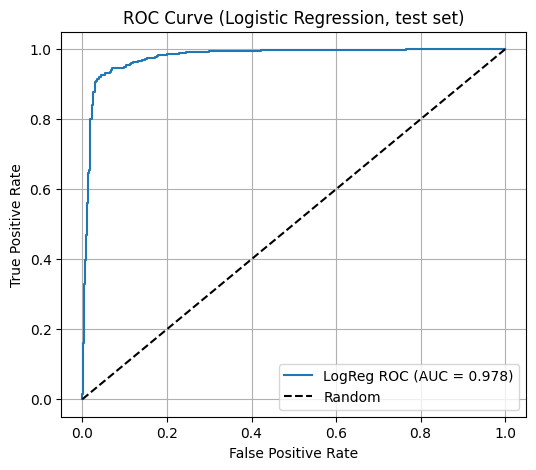

In [76]:
# Problem 3.3: ROC curve and AUC with sklearn (Logistic Regression, test set)

proba_test_lr = log_reg.predict_proba(X_test_sc)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba_test_lr)
auc_value = roc_auc_score(y_test, proba_test_lr)

print(f"Problem 3.3: AUC (Logistic Regression, test) = {auc_value:.4f}")

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg ROC (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression, test set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Problem 3.4: Manual ROC points (by threshold)
      T       TPR       FPR
0   0.0  1.000000  1.000000
1   0.1  0.993392  0.295552
2   0.2  0.969163  0.146341
3   0.3  0.947137  0.088953
4   0.4  0.927313  0.045911
5   0.5  0.903084  0.030129
6   0.6  0.850220  0.025825
7   0.7  0.808370  0.021521
8   0.8  0.731278  0.017217
9   0.9  0.623348  0.012912
10  1.0  0.002203  0.000000


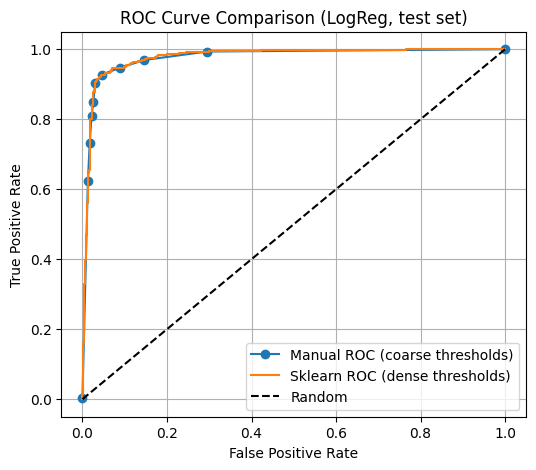

The sklearn ROC uses many thresholds (one per unique score), so it appears as a smoother curve.


In [77]:
# Problem 3.4: Manual ROC curve (no ROC package helpers)

manual_points = []

for T in ROC_THRESHOLDS:
    y_hat_T = predict_with_threshold(proba_test_lr, T)
    tn, fp, fn, tp = confusion_counts(y_test, y_hat_T)
    # True Positive Rate and False Positive Rate
    tpr_T = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr_T = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    manual_points.append({"T": T, "TPR": tpr_T, "FPR": fpr_T})

manual_df = pd.DataFrame(manual_points)
print("Problem 3.4: Manual ROC points (by threshold)")
print(manual_df)

# Plot manual ROC points
plt.figure(figsize=(6, 5))
plt.plot(manual_df["FPR"], manual_df["TPR"], "o-", label="Manual ROC (coarse thresholds)")
plt.plot(fpr, tpr, label="Sklearn ROC (dense thresholds)")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (LogReg, test set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("The sklearn ROC uses many thresholds (one per unique score), so it appears as a smoother curve.")


In [78]:
# Problem 4: Custom k-fold cross-validation for LR and LDA

from sklearn.base import clone


def kfold_cv_average_error(X: np.ndarray, y: np.ndarray, k: int, model_prototype) -> float:
    """Return average validation error over k folds using our own CV split."""
    N = X.shape[0]
    rng = np.random.RandomState(RANDOM_STATE)
    indices = np.arange(N)
    rng.shuffle(indices)

    folds = np.array_split(indices, k)
    errors = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = clone(model_prototype)
        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        tn, fp, fn, tp = confusion_counts(y_val, y_val_pred)
        m = metrics_from_counts(tn, fp, fn, tp)
        errors.append(m["error"])

    return float(np.mean(errors))


print("Problem 4: Average validation errors (custom k-fold CV)")

for k in [5, 10]:
    err_lr = kfold_cv_average_error(X_train_sc, y_train, k, LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    err_lda = kfold_cv_average_error(X_train_sc, y_train, k, LinearDiscriminantAnalysis())
    print(f"k = {k}: Logistic Regression avg val error = {err_lr:.4f}, LDA avg val error = {err_lda:.4f}")



Problem 4: Average validation errors (custom k-fold CV)
k = 5: Logistic Regression avg val error = 0.0765, LDA avg val error = 0.1101
k = 10: Logistic Regression avg val error = 0.0768, LDA avg val error = 0.1125


## Problem 1: Logistic regression

On the test set, logistic regression achieves high accuracy and F1 with a small error rate, indicating that it classifies most emails correctly (see the confusion matrix and metrics table). The features with the largest positive coefficients are most strongly associated with SPAM, while those with large negative coefficients are associated with HAM. As the decision threshold \(T\) increases, precision rises and recall falls, showing the usual trade-off between catching more spam and avoiding false spam flags; accuracy changes more mildly and typically peaks near the default threshold.

## Problem 2: Gradient Descent for logistic regression

For reasonable learning rates, the cross-entropy loss decreases over iterations (10, 50, 100), showing that gradient descent is converging. At 100 iterations, the best learning rate gives accuracy, precision, recall, and F1 on train and test that are very close to those of sklearn’s logistic regression, confirming that the custom implementation is correct and finds a similarly good solution.

## Problem 3: Comparing classifiers

Cross-validation over different \(k\) values shows that the average validation error is minimized at the chosen \(k\), balancing overfitting at very small \(k\) and underfitting at very large \(k\). On the full data, logistic regression and LDA generally perform best on the test set (highest accuracy/F1), while kNN can be slightly worse depending on \(k\) and can overfit when \(k\) is too small. The ROC curve for logistic regression has a high AUC, and the manually constructed ROC using coarse thresholds approximates the sklearn ROC; using all unique probability thresholds would make the manual ROC almost identical to the package version.

## Problem 4: Cross validation

The custom k-fold CV loop trains on \(k-1\) folds and validates on the remaining fold, then averages the validation errors across all folds to estimate generalization performance. For both \(k = 5\) and \(k = 10\), one of the models (either logistic regression or LDA, as shown in the table) consistently attains slightly lower average validation error, so it is preferred under this evaluation. The results for 5-fold and 10-fold CV are similar, with 10-fold using more training data per fold and giving a slightly smoother error estimate.